<a href="https://colab.research.google.com/github/epicariello/zone30/blob/main/Zone30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ultimo aggiornamento:** 27 marzo 2026, ore 14:45 UTC  
**Branch:** `claude/urban-comparison-PI9se`  
**Commit:** Unified 5-series comparison plots (incidenti/1000ab, gravità) for BO/OL vs IT/ER/SA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Questo notebook è stato utilizzato per la realizzazione della tesi L'effetto dell'istituzione della zona 30 km/h sulla mortalità negli incidenti automobilistici**
  

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import unicodedata

# Carica Comuni Emilia-Romagna
df_comuni_emilia_romagna = pd.read_excel('/content/drive/MyDrive/TesiMagistrale/FontiUsate/Comuni_Emilia_Romagna.xlsx')
print(f'✅ Emilia-Romagna: {len(df_comuni_emilia_romagna)} comuni')

# Carica Comuni Sardegna
df_comuni_sardegna = pd.read_excel('/content/drive/MyDrive/TesiMagistrale/FontiUsate/Comuni_Sardegna.xlsx')
print(f'✅ Sardegna: {len(df_comuni_sardegna)} comuni')


✅ Emilia-Romagna: 330 comuni
✅ Sardegna: 377 comuni


In [ ]:
import pandas as pd

# Carica il CSV della popolazione per comune per anno
df_pop = pd.read_csv(
    '/content/drive/MyDrive/TesiMagistrale/FontiUsate/popolazione_comuni_per_anno.csv',
    sep=';',
    decimal=',',
    encoding='latin-1'
)
df_pop = df_pop.rename(columns={'codice': 'Codice', 'comune': 'Comune'})
print(f'✅ df_pop pronto: {df_pop.shape[0]:,} comuni')
print(f'Colonne: {df_pop.columns.tolist()[:6]} ...')


✅ df_pop pronto: 7,991 comuni
Colonne: ['Codice', 'Comune', '2002', '2003', '2004', '2005'] ...


In [ ]:
import unicodedata, pandas as pd, numpy as np

def normalizza(s):
    """Rimuove accenti e apostrofi, lowercase — per join robusto sui nomi comuni."""
    s = str(s).strip().lower()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    return s.replace("'", "").replace("`", "")

anni_plot = list(range(2015, 2025))

# ── Caricamento incidenti_urbani ────────────────────────────────────────
df_urban = pd.read_csv(
    '/content/drive/MyDrive/TesiMagistrale/FontiUsate/incidenti_urbani.csv',
    sep=';', encoding='utf-8'
)
df_urban = df_urban.rename(columns={'nome_comune': 'Comune'})
df_urban['_key'] = df_urban['Comune'].apply(normalizza)

# ── Join con popolazione ────────────────────────────────────────────────
df_pop_tmp = df_pop.copy()
df_pop_tmp['_key'] = df_pop_tmp['Comune'].apply(normalizza)
pop_cols = ['_key'] + [str(a) for a in anni_plot]
df_m = df_urban.merge(df_pop_tmp[pop_cols], on='_key', how='left')

# ── Maschere gruppi ─────────────────────────────────────────────────────
er_keys   = {normalizza(k) for k in df_comuni_emilia_romagna['Comune'].str.strip()}
sard_keys = {normalizza(k) for k in df_comuni_sardegna['Comune'].str.strip()}

is_bo = df_m['_key'] == normalizza('bologna')
is_ol = df_m['_key'] == normalizza('olbia')
is_er = df_m['_key'].isin(er_keys) & ~is_bo
is_sa = df_m['_key'].isin(sard_keys) & ~is_ol
is_it = ~is_bo & ~is_ol

print(f'incidenti_urbani: {len(df_urban):,} comuni, anni 2010–2024')
print(f'Bologna: {is_bo.sum()} | Olbia: {is_ol.sum()} | ER: {is_er.sum()} | SA: {is_sa.sum()} | IT (excl. BO+OL): {is_it.sum()}')
n_no_pop = df_m[str(anni_plot[0])].isna().sum()
print(f'Comuni senza dato popolazione: {n_no_pop:,} su {len(df_m):,}')


incidenti_urbani: 7,384 comuni, anni 2010–2024
Bologna: 1 | Olbia: 1 | ER: 328 | SA: 324 | IT (excl. BO+OL): 7399
Comuni senza dato popolazione: 399 su 7,401


In [ ]:
def inc_per_1000(mask):
    """Incidenti ogni 1.000 abitanti per gruppo, anni 2015–2024."""
    vals = []
    for anno in anni_plot:
        inc = pd.to_numeric(df_m.loc[mask, f'{anno}_incidenti'], errors='coerce').sum()
        pop = pd.to_numeric(df_m.loc[mask, str(anno)], errors='coerce').sum()
        vals.append(inc / pop * 1000 if pop > 0 else float('nan'))
    return vals

def gravita(mask):
    """(Morti+Feriti)/Incidenti per gruppo, anni 2015–2024."""
    vals = []
    for anno in anni_plot:
        morti  = pd.to_numeric(df_m.loc[mask, f'{anno}_morti'],     errors='coerce').sum()
        feriti = pd.to_numeric(df_m.loc[mask, f'{anno}_feriti'],    errors='coerce').sum()
        inc    = pd.to_numeric(df_m.loc[mask, f'{anno}_incidenti'], errors='coerce').sum()
        vals.append((morti + feriti) / inc if inc > 0 else float('nan'))
    return vals

s_bo_inc,  s_bo_grav  = inc_per_1000(is_bo), gravita(is_bo)
s_ol_inc,  s_ol_grav  = inc_per_1000(is_ol), gravita(is_ol)
s_it_inc,  s_it_grav  = inc_per_1000(is_it), gravita(is_it)
s_er_inc,  s_er_grav  = inc_per_1000(is_er), gravita(is_er)
s_sa_inc,  s_sa_grav  = inc_per_1000(is_sa), gravita(is_sa)

print('✅ Serie temporali calcolate (2015–2024):')
print(f'  Bologna  inc/1000ab: {[round(v,3) for v in s_bo_inc]}')
print(f'  Olbia    inc/1000ab: {[round(v,3) for v in s_ol_inc]}')


✅ Serie temporali calcolate (2015–2024):
  Bologna  inc/1000ab: [np.float64(4.278), np.float64(4.411), np.float64(4.471), np.float64(4.625), np.float64(4.491), np.float64(2.964), np.float64(4.486), np.float64(4.935), np.float64(4.99), np.float64(4.542)]
  Olbia    inc/1000ab: [np.float64(4.274), np.float64(3.674), np.float64(4.146), np.float64(3.296), np.float64(3.507), np.float64(2.726), np.float64(2.903), np.float64(3.327), np.float64(3.711), np.float64(3.595)]


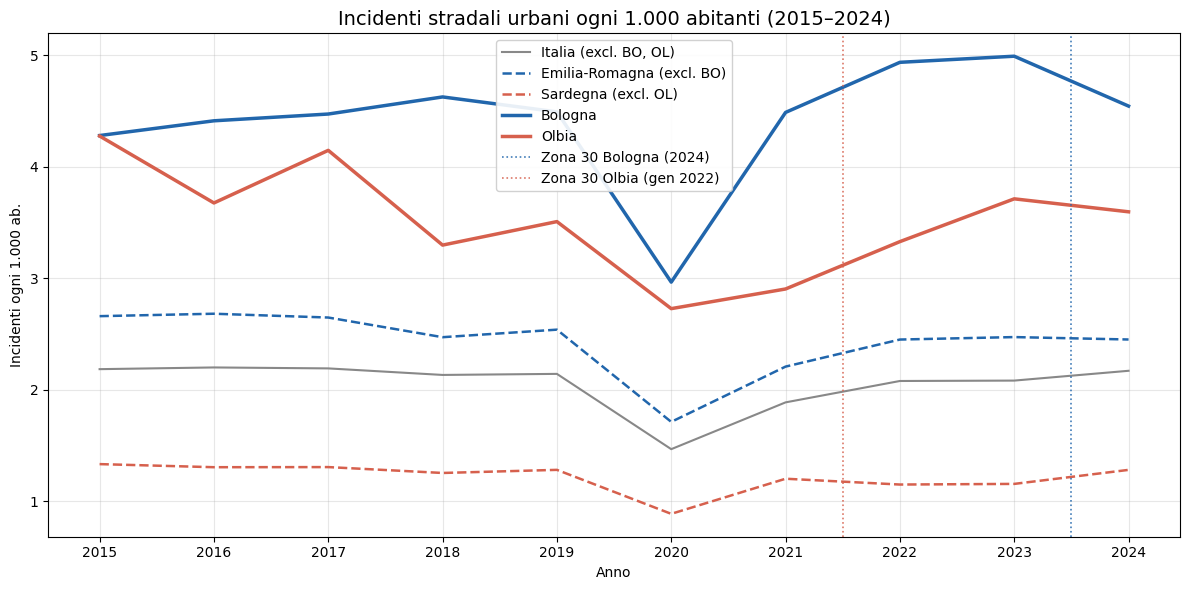

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

C_BO = '#2166ac'   # blu — Bologna / Emilia-Romagna
C_OL = '#d6604d'   # rosso-arancio — Olbia / Sardegna
C_IT = '#888888'   # grigio — Italia

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(anni_plot, s_it_inc, color=C_IT, lw=1.5,  ls='-',  label='Italia (escl. BO, OL)')
ax.plot(anni_plot, s_er_inc, color=C_BO, lw=1.8,  ls='--', label='Emilia-Romagna (escl. BO)')
ax.plot(anni_plot, s_sa_inc, color=C_OL, lw=1.8,  ls='--', label='Sardegna (escl. OL)')
ax.plot(anni_plot, s_bo_inc, color=C_BO, lw=2.5,  ls='-',  label='Bologna')
ax.plot(anni_plot, s_ol_inc, color=C_OL, lw=2.5,  ls='-',  label='Olbia')

ax.axvline(x=2023.5, color=C_BO, lw=1.2, ls=':', alpha=0.85, label='Zona 30 Bologna (gen 2024)')
ax.axvline(x=2021.5, color=C_OL, lw=1.2, ls=':', alpha=0.85, label='Zona 30 Olbia (giu 2021)')

ax.set_title('Incidenti stradali urbani ogni 1.000 abitanti (2015\u20132024)', fontsize=14)
ax.set_xlabel('Anno')
ax.set_ylabel('Incidenti ogni 1.000 ab.')
ax.set_xticks(anni_plot)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_inc = pd.DataFrame({
    'Anno':                    anni_plot,
    'Bologna':                 [round(v, 3) for v in s_bo_inc],
    'Olbia':                   [round(v, 3) for v in s_ol_inc],
    'Italia (escl. BO, OL)':   [round(v, 3) for v in s_it_inc],
    'Emilia-R. (escl. BO)':    [round(v, 3) for v in s_er_inc],
    'Sardegna (escl. OL)':     [round(v, 3) for v in s_sa_inc],
}).set_index('Anno')

display(df_inc.style
    .set_caption("Incidenti stradali urbani ogni 1.000 abitanti")
    .format("{:.3f}")
    .highlight_min(axis=1, color='#d4f4dd')
    .highlight_max(axis=1, color='#ffd4d4')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}]))

,Bologna,Olbia,"Italia (escl. BO, OL)",Emilia-R. (escl. BO),Sardegna (escl. OL)
Anno,,,,,
2015,4.278,4.274,2.184,2.659,1.332
2016,4.411,3.674,2.199,2.681,1.304
2017,4.471,4.146,2.190,2.647,1.305
2018,4.625,3.296,2.132,2.470,1.253
2019,4.491,3.507,2.141,2.538,1.281
2020,2.964,2.726,1.466,1.711,0.886
2021,4.486,2.903,1.886,2.206,1.201
2022,4.935,3.327,2.078,2.449,1.149
2023,4.990,3.711,2.081,2.471,1.155


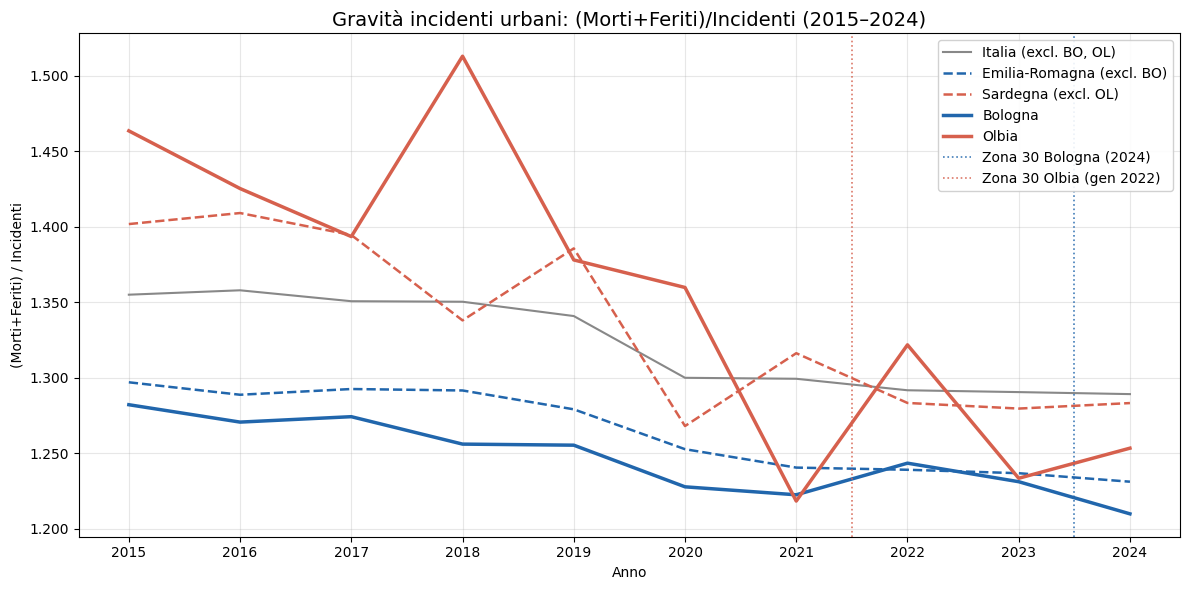

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(anni_plot, s_it_grav, color=C_IT, lw=1.5,  ls='-',  label='Italia (escl. BO, OL)')
ax.plot(anni_plot, s_er_grav, color=C_BO, lw=1.8,  ls='--', label='Emilia-Romagna (escl. BO)')
ax.plot(anni_plot, s_sa_grav, color=C_OL, lw=1.8,  ls='--', label='Sardegna (escl. OL)')
ax.plot(anni_plot, s_bo_grav, color=C_BO, lw=2.5,  ls='-',  label='Bologna')
ax.plot(anni_plot, s_ol_grav, color=C_OL, lw=2.5,  ls='-',  label='Olbia')

ax.axvline(x=2023.5, color=C_BO, lw=1.2, ls=':', alpha=0.85, label='Zona 30 Bologna (gen 2024)')
ax.axvline(x=2021.5, color=C_OL, lw=1.2, ls=':', alpha=0.85, label='Zona 30 Olbia (giu 2021)')

ax.set_title('Gravit\u00e0 incidenti urbani: (Morti+Feriti)/Incidenti (2015\u20132024)', fontsize=14)
ax.set_xlabel('Anno')
ax.set_ylabel('(Morti+Feriti) / Incidenti')
ax.set_xticks(anni_plot)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_grav = pd.DataFrame({
    'Anno':                    anni_plot,
    'Bologna':                 [round(v, 4) for v in s_bo_grav],
    'Olbia':                   [round(v, 4) for v in s_ol_grav],
    'Italia (escl. BO, OL)':   [round(v, 4) for v in s_it_grav],
    'Emilia-R. (escl. BO)':    [round(v, 4) for v in s_er_grav],
    'Sardegna (escl. OL)':     [round(v, 4) for v in s_sa_grav],
}).set_index('Anno')

display(df_grav.style
    .set_caption("Gravità incidenti urbani (Morti+Feriti) / Incidenti")
    .format("{:.4f}")
    .highlight_min(axis=1, color='#d4f4dd')
    .highlight_max(axis=1, color='#ffd4d4')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}]))

,Bologna,Olbia,"Italia (escl. BO, OL)",Emilia-R. (escl. BO),Sardegna (escl. OL)
Anno,,,,,
2015,1.2822,1.4634,1.3550,1.2970,1.4017
2016,1.2707,1.4252,1.3579,1.2888,1.4090
2017,1.2742,1.3934,1.3507,1.2925,1.3945
2018,1.2561,1.5128,1.3503,1.2916,1.3380
2019,1.2554,1.3780,1.3408,1.2791,1.3856
2020,1.2278,1.3598,1.3000,1.2527,1.2680
2021,1.2225,1.2184,1.2993,1.2405,1.3163
2022,1.2435,1.3218,1.2917,1.2391,1.2833
2023,1.2312,1.2335,1.2905,1.2368,1.2796


In [ ]:
# Esporta entrambi i dataframe in un unico file Excel con due fogli
with pd.ExcelWriter('Analisi_Zone30.xlsx', engine='openpyxl') as writer:
    df_inc.to_excel(writer, sheet_name='Frequenza_Incidenti', index=True)
    df_grav.to_excel(writer, sheet_name='Gravita_Incidenti', index=True)

# Scarica il file
from google.colab import files
files.download('Analisi_Zone30.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

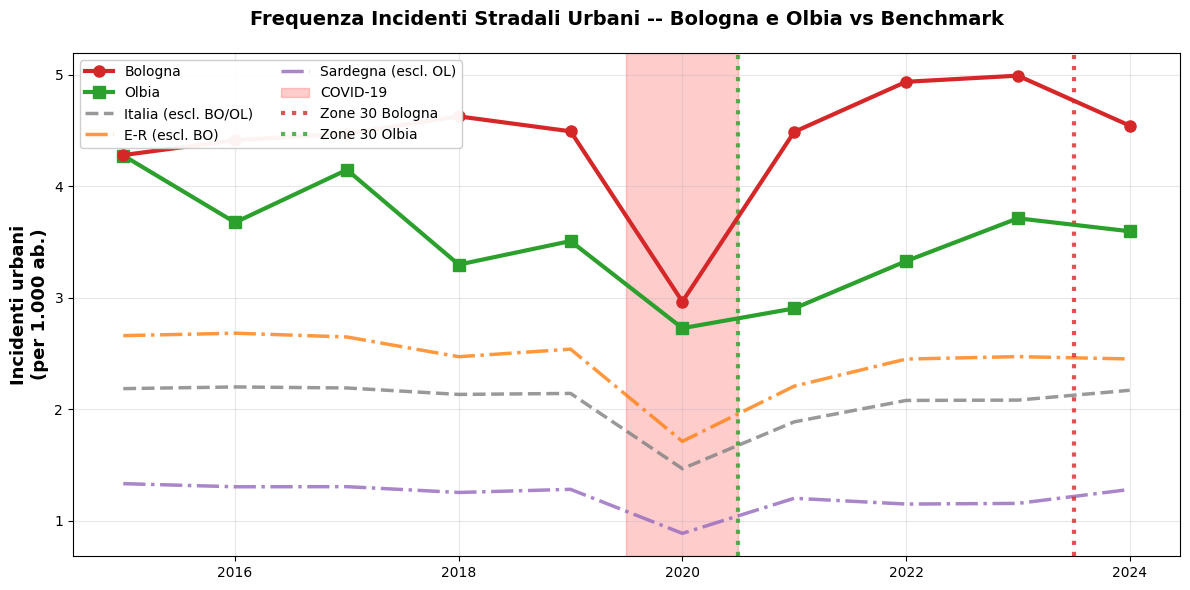

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

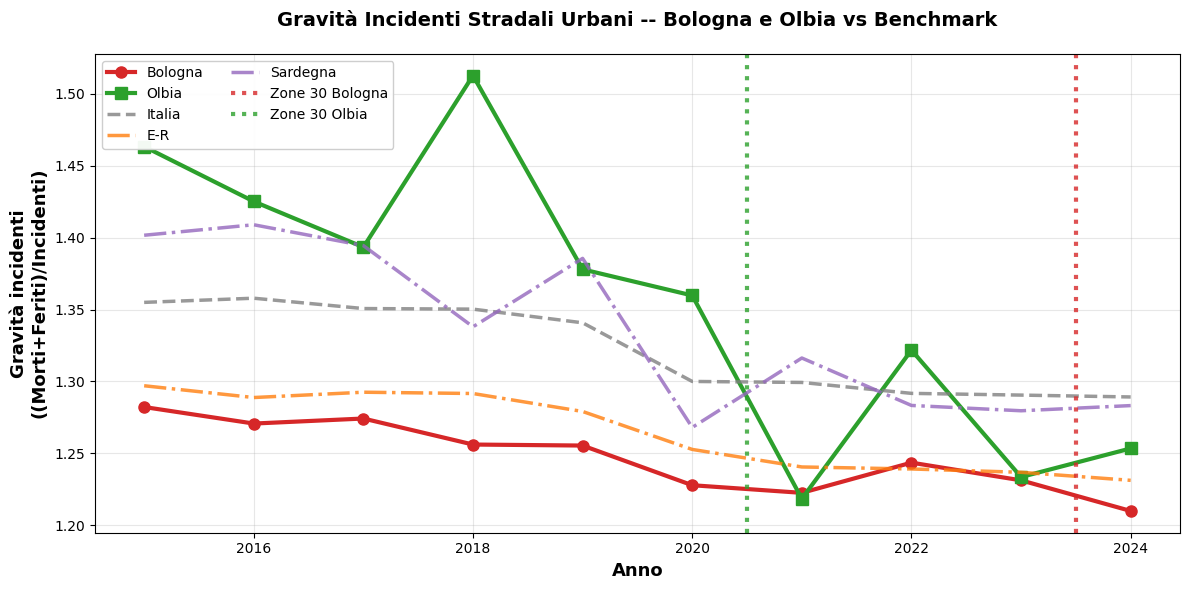

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# GRAFICO 1: Solo FREQUENZA (df_inc)
fig1, ax1 = plt.subplots(figsize=(12, 6))

anni = df_inc.index.tolist()

ax1.plot(anni, df_inc['Bologna'], 'o-', linewidth=3, markersize=8,
         color='#d62728', label='Bologna', zorder=5)
ax1.plot(anni, df_inc['Olbia'], 's-', linewidth=3, markersize=8,
         color='#2ca02c', label='Olbia', zorder=4)
ax1.plot(anni, df_inc['Italia (escl. BO, OL)'], '--', linewidth=2.5,
         color='gray', alpha=0.8, label='Italia (escl. BO/OL)')
ax1.plot(anni, df_inc['Emilia-R. (escl. BO)'], '-.', linewidth=2.5,
         color='#ff7f0e', alpha=0.8, label="E-R (escl. BO)")
ax1.plot(anni, df_inc['Sardegna (escl. OL)'], '-.', linewidth=2.5,
         color='#9467bd', alpha=0.8, label="Sardegna (escl. OL)")

# Evidenziazioni
ax1.axvspan(2019.5, 2020.5, alpha=0.2, color='red', label='COVID-19')
ax1.axvline(x=2023.5, color='#d62728', linestyle=':', linewidth=3, alpha=0.8, label='Zone 30 Bologna')
ax1.axvline(x=2020.5, color='#2ca02c', linestyle=':', linewidth=3, alpha=0.8, label='Zone 30 Olbia')

ax1.set_ylabel('Incidenti urbani\n(per 1.000 ab.)', fontsize=13, fontweight='bold')
ax1.set_title('Frequenza Incidenti Stradali Urbani -- Bologna e Olbia vs Benchmark',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left', framealpha=0.95, fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_frequenza_incidenti.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
files.download('grafico_frequenza_incidenti.png')

# GRAFICO 2: Solo GRAVITÀ (df_grav)
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(anni, df_grav['Bologna'], 'o-', linewidth=3, markersize=8,
         color='#d62728', label='Bologna')
ax2.plot(anni, df_grav['Olbia'], 's-', linewidth=3, markersize=8,
         color='#2ca02c', label='Olbia')
ax2.plot(anni, df_grav['Italia (escl. BO, OL)'], '--', linewidth=2.5,
         color='gray', alpha=0.8, label='Italia')
ax2.plot(anni, df_grav['Emilia-R. (escl. BO)'], '-.', linewidth=2.5,
         color='#ff7f0e', alpha=0.8, label="E-R")
ax2.plot(anni, df_grav['Sardegna (escl. OL)'], '-.', linewidth=2.5,
         color='#9467bd', alpha=0.8, label="Sardegna")

# Solo Zone 30 (COVID già nel primo grafico)
ax2.axvline(x=2023.5, color='#d62728', linestyle=':', linewidth=3, alpha=0.8, label='Zone 30 Bologna')
ax2.axvline(x=2020.5, color='#2ca02c', linestyle=':', linewidth=3, alpha=0.8, label='Zone 30 Olbia')

ax2.set_xlabel('Anno', fontsize=13, fontweight='bold')
ax2.set_ylabel('Gravità incidenti\n((Morti+Feriti)/Incidenti)', fontsize=13, fontweight='bold')
ax2.set_title('Gravità Incidenti Stradali Urbani -- Bologna e Olbia vs Benchmark',
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper left', framealpha=0.95, fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_gravita_incidenti.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
files.download('grafico_gravita_incidenti.png')

In [22]:
# BOLOGNA
# Pre-Z30: 2015-2019 + 2021-2023 (senza 2020 COVID, senza 2024 post-Z30)
# Post-Z30: 2024

anni_pre_bo = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023]
anni_post_bo = [2024]

# Frequenza
freq_bo_pre = df_inc.loc[anni_pre_bo, 'Bologna'].mean()
freq_bo_post = df_inc.loc[anni_post_bo, 'Bologna'].mean()
freq_it_pre = df_inc.loc[anni_pre_bo, 'Italia (escl. BO, OL)'].mean()
freq_it_post = df_inc.loc[anni_post_bo, 'Italia (escl. BO, OL)'].mean()
freq_er_pre = df_inc.loc[anni_pre_bo, 'Emilia-R. (escl. BO)'].mean()
freq_er_post = df_inc.loc[anni_post_bo, 'Emilia-R. (escl. BO)'].mean()

# Gravità
grav_bo_pre = df_grav.loc[anni_pre_bo, 'Bologna'].mean()
grav_bo_post = df_grav.loc[anni_post_bo, 'Bologna'].mean()
grav_it_pre = df_grav.loc[anni_pre_bo, 'Italia (escl. BO, OL)'].mean()
grav_it_post = df_grav.loc[anni_post_bo, 'Italia (escl. BO, OL)'].mean()
grav_er_pre = df_grav.loc[anni_pre_bo, 'Emilia-R. (escl. BO)'].mean()
grav_er_post = df_grav.loc[anni_post_bo, 'Emilia-R. (escl. BO)'].mean()

print("=== BOLOGNA ===")
print(f"\nFREQUENZA (incidenti/1.000 ab.)")
print(f"Bologna  pre-Z30:  {freq_bo_pre:.3f}  |  post-Z30: {freq_bo_post:.3f}  |  var: {(freq_bo_post/freq_bo_pre-1)*100:+.1f}%")
print(f"Italia   pre-Z30:  {freq_it_pre:.3f}  |  post-Z30: {freq_it_post:.3f}  |  var: {(freq_it_post/freq_it_pre-1)*100:+.1f}%")
print(f"E-R      pre-Z30:  {freq_er_pre:.3f}  |  post-Z30: {freq_er_post:.3f}  |  var: {(freq_er_post/freq_er_pre-1)*100:+.1f}%")

print(f"\nGRAVITÀ ((M+F)/Inc.)")
print(f"Bologna  pre-Z30:  {grav_bo_pre:.4f}  |  post-Z30: {grav_bo_post:.4f}  |  var: {(grav_bo_post/grav_bo_pre-1)*100:+.1f}%")
print(f"Italia   pre-Z30:  {grav_it_pre:.4f}  |  post-Z30: {grav_it_post:.4f}  |  var: {(grav_it_post/grav_it_pre-1)*100:+.1f}%")
print(f"E-R      pre-Z30:  {grav_er_pre:.4f}  |  post-Z30: {grav_er_post:.4f}  |  var: {(grav_er_post/grav_er_pre-1)*100:+.1f}%")

print(f"\nDIVARIO frequenza Bologna vs Italia pre-Z30: {(freq_bo_pre/freq_it_pre-1)*100:+.1f}%")
print(f"DIVARIO frequenza Bologna vs E-R pre-Z30:   {(freq_bo_pre/freq_er_pre-1)*100:+.1f}%")
print(f"DIVARIO gravità   Bologna vs Italia pre-Z30: {(grav_bo_pre/grav_it_pre-1)*100:+.1f}%")
print(f"DIVARIO gravità   Bologna vs E-R pre-Z30:   {(grav_bo_pre/grav_er_pre-1)*100:+.1f}%")

=== BOLOGNA ===

FREQUENZA (incidenti/1.000 ab.)
Bologna  pre-Z30:  4.586  |  post-Z30: 4.542  |  var: -1.0%
Italia   pre-Z30:  2.111  |  post-Z30: 2.169  |  var: +2.7%
E-R      pre-Z30:  2.515  |  post-Z30: 2.450  |  var: -2.6%

GRAVITÀ ((M+F)/Inc.)
Bologna  pre-Z30:  1.2545  |  post-Z30: 1.2099  |  var: -3.6%
Italia   pre-Z30:  1.3295  |  post-Z30: 1.2892  |  var: -3.0%
E-R      pre-Z30:  1.2707  |  post-Z30: 1.2312  |  var: -3.1%

DIVARIO frequenza Bologna vs Italia pre-Z30: +117.2%
DIVARIO frequenza Bologna vs E-R pre-Z30:   +82.3%
DIVARIO gravità   Bologna vs Italia pre-Z30: -5.6%
DIVARIO gravità   Bologna vs E-R pre-Z30:   -1.3%


In [23]:
# OLBIA
# Pre-Z30: 2015-2019 (senza 2020 COVID)
# Post-Z30: 2022-2024 (2021 è anno parziale, scarto)

anni_pre_ol = [2015, 2016, 2017, 2018, 2019]
anni_post_ol = [2022, 2023, 2024]

# Frequenza
freq_ol_pre = df_inc.loc[anni_pre_ol, 'Olbia'].mean()
freq_ol_post = df_inc.loc[anni_post_ol, 'Olbia'].mean()
freq_it_pre_ol = df_inc.loc[anni_pre_ol, 'Italia (escl. BO, OL)'].mean()
freq_it_post_ol = df_inc.loc[anni_post_ol, 'Italia (escl. BO, OL)'].mean()
freq_sa_pre = df_inc.loc[anni_pre_ol, 'Sardegna (escl. OL)'].mean()
freq_sa_post = df_inc.loc[anni_post_ol, 'Sardegna (escl. OL)'].mean()

# Gravità
grav_ol_pre = df_grav.loc[anni_pre_ol, 'Olbia'].mean()
grav_ol_post = df_grav.loc[anni_post_ol, 'Olbia'].mean()
grav_it_pre_ol = df_grav.loc[anni_pre_ol, 'Italia (escl. BO, OL)'].mean()
grav_it_post_ol = df_grav.loc[anni_post_ol, 'Italia (escl. BO, OL)'].mean()
grav_sa_pre = df_grav.loc[anni_pre_ol, 'Sardegna (escl. OL)'].mean()
grav_sa_post = df_grav.loc[anni_post_ol, 'Sardegna (escl. OL)'].mean()

print("=== OLBIA ===")
print(f"\nFREQUENZA (incidenti/1.000 ab.)")
print(f"Olbia     pre-Z30:  {freq_ol_pre:.3f}  |  post-Z30: {freq_ol_post:.3f}  |  var: {(freq_ol_post/freq_ol_pre-1)*100:+.1f}%")
print(f"Italia    pre-Z30:  {freq_it_pre_ol:.3f}  |  post-Z30: {freq_it_post_ol:.3f}  |  var: {(freq_it_post_ol/freq_it_pre_ol-1)*100:+.1f}%")
print(f"Sardegna  pre-Z30:  {freq_sa_pre:.3f}  |  post-Z30: {freq_sa_post:.3f}  |  var: {(freq_sa_post/freq_sa_pre-1)*100:+.1f}%")

print(f"\nGRAVITÀ ((M+F)/Inc.)")
print(f"Olbia     pre-Z30:  {grav_ol_pre:.4f}  |  post-Z30: {grav_ol_post:.4f}  |  var: {(grav_ol_post/grav_ol_pre-1)*100:+.1f}%")
print(f"Italia    pre-Z30:  {grav_it_pre_ol:.4f}  |  post-Z30: {grav_it_post_ol:.4f}  |  var: {(grav_it_post_ol/grav_it_pre_ol-1)*100:+.1f}%")
print(f"Sardegna  pre-Z30:  {grav_sa_pre:.4f}  |  post-Z30: {grav_sa_post:.4f}  |  var: {(grav_sa_post/grav_sa_pre-1)*100:+.1f}%")

print(f"\nDIVARIO frequenza Olbia vs Italia pre-Z30:    {(freq_ol_pre/freq_it_pre_ol-1)*100:+.1f}%")
print(f"DIVARIO frequenza Olbia vs Sardegna pre-Z30:  {(freq_ol_pre/freq_sa_pre-1)*100:+.1f}%")
print(f"DIVARIO gravità   Olbia vs Italia pre-Z30:    {(grav_ol_pre/grav_it_pre_ol-1)*100:+.1f}%")
print(f"DIVARIO gravità   Olbia vs Sardegna pre-Z30:  {(grav_ol_pre/grav_sa_pre-1)*100:+.1f}%")

=== OLBIA ===

FREQUENZA (incidenti/1.000 ab.)
Olbia     pre-Z30:  3.779  |  post-Z30: 3.544  |  var: -6.2%
Italia    pre-Z30:  2.169  |  post-Z30: 2.109  |  var: -2.8%
Sardegna  pre-Z30:  1.295  |  post-Z30: 1.195  |  var: -7.7%

GRAVITÀ ((M+F)/Inc.)
Olbia     pre-Z30:  1.4346  |  post-Z30: 1.2696  |  var: -11.5%
Italia    pre-Z30:  1.3509  |  post-Z30: 1.2905  |  var: -4.5%
Sardegna  pre-Z30:  1.3858  |  post-Z30: 1.2820  |  var: -7.5%

DIVARIO frequenza Olbia vs Italia pre-Z30:    +74.2%
DIVARIO frequenza Olbia vs Sardegna pre-Z30:  +191.8%
DIVARIO gravità   Olbia vs Italia pre-Z30:    +6.2%
DIVARIO gravità   Olbia vs Sardegna pre-Z30:  +3.5%
